# TransferBench

## Experiment 2

# ResNet18 Fine-Tuning

This notebook evaluates ResNet18 using Partial Fine-Tuning.

Unlike the previous experiment, the final residual block (Layer4) is unfrozen and optimized together with the classifier.

Objectives

- Partial Fine-Tuning
- Performance Evaluation
- Benchmark Comparison

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project Root:", PROJECT_ROOT)

Project Root: C:\Users\pc1\TransferBench


In [2]:
from utils.dataset import load_dataset

print("Dataset Imported Successfully")

Import OK ✅
Dataset Imported Successfully


In [3]:
import torch
import torch.nn as nn

from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from utils.dataset import load_dataset

from utils.models import build_model

from utils.training import (
    train_model,
    print_summary,
)

from utils.evaluation import (
    calculate_metrics,
    print_metrics,
    export_metrics_csv,
)

from utils.visualization import (
    plot_loss_curve,
    plot_accuracy_curve,
    plot_confusion_matrix,
)

from utils.paths import *

In [4]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"

)

print(device)

cuda


In [5]:
train_loader, test_loader, class_names = load_dataset(
    dataset_name="cifar10",
    batch_size=32,
    image_size=224,
)

C:\Users\pc1\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Build ResNet18 Model

In [6]:
model = build_model(
    model_name="resnet18",
    num_classes=10,
    strategy="finetune",
)

model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## Loss Function and Optimizer

In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
)

optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)

In [8]:
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

scheduler

## Training Configuration

In [9]:
EPOCHS = 20

checkpoint_path = get_model_path(
    "best_resnet18_finetune"
)

print(checkpoint_path)

C:\Users\pc1\TransferBench\models\best_resnet18_finetune.pth


## Train Model

In [10]:
results = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=EPOCHS,
    device=device,
    checkpoint_path=checkpoint_path,
)

Training Started
Epoch 01/20 | Train Loss: 0.4492 | Train Acc: 0.8486 | Val Loss: 0.2706 | Val Acc: 0.9064
Epoch 02/20 | Train Loss: 0.2609 | Train Acc: 0.9105 | Val Loss: 0.2333 | Val Acc: 0.9193
Epoch 03/20 | Train Loss: 0.1985 | Train Acc: 0.9326 | Val Loss: 0.2286 | Val Acc: 0.9227
Epoch 04/20 | Train Loss: 0.1553 | Train Acc: 0.9466 | Val Loss: 0.2215 | Val Acc: 0.9256
Epoch 05/20 | Train Loss: 0.1294 | Train Acc: 0.9562 | Val Loss: 0.2156 | Val Acc: 0.9315
Epoch 06/20 | Train Loss: 0.1070 | Train Acc: 0.9634 | Val Loss: 0.2154 | Val Acc: 0.9306
Epoch 07/20 | Train Loss: 0.0876 | Train Acc: 0.9702 | Val Loss: 0.2225 | Val Acc: 0.9334
Epoch 08/20 | Train Loss: 0.0804 | Train Acc: 0.9728 | Val Loss: 0.2173 | Val Acc: 0.9325
Epoch 09/20 | Train Loss: 0.0717 | Train Acc: 0.9758 | Val Loss: 0.2189 | Val Acc: 0.9338
Epoch 10/20 | Train Loss: 0.0599 | Train Acc: 0.9799 | Val Loss: 0.2272 | Val Acc: 0.9353
Epoch 11/20 | Train Loss: 0.0572 | Train Acc: 0.9807 | Val Loss: 0.2478 | Val Acc: 

## Evaluation

In [11]:
metrics = calculate_metrics(
    results["targets"],
    results["predictions"],
)

print_metrics(metrics)

Evaluation Results
Accuracy  : 0.9399
Precision : 0.9401
Recall    : 0.9399
F1 Score  : 0.9398


In [12]:
metrics_df = export_metrics_csv(
    metrics=metrics,
    model_name="ResNet18",
    strategy="Fine-Tuning",
    training_time=results["training_time"],
    save_path=get_metrics_path("resnet18_finetune"),
)

metrics_df

,Model,Strategy,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,ResNet18,Fine-Tuning,0.9399,0.940089,0.9399,0.939756,1634.346132


## Training Curves

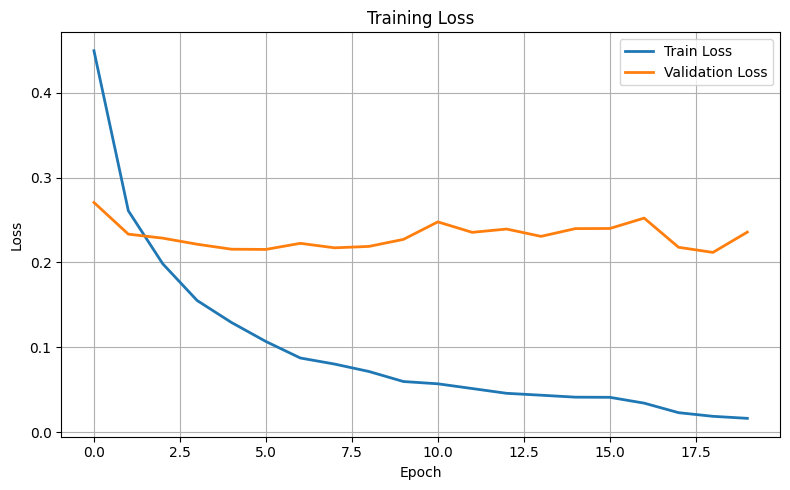

In [13]:
plot_loss_curve(
    history=results["history"],
    save_path=get_loss_plot_path("resnet18_finetune"),
)

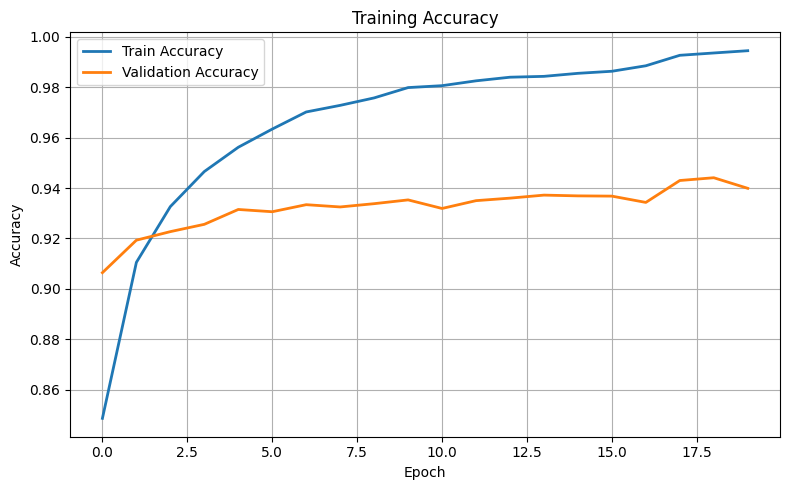

In [14]:
plot_accuracy_curve(
    history=results["history"],
    save_path=get_accuracy_plot_path("resnet18_finetune"),
)

## Confusion Matrix

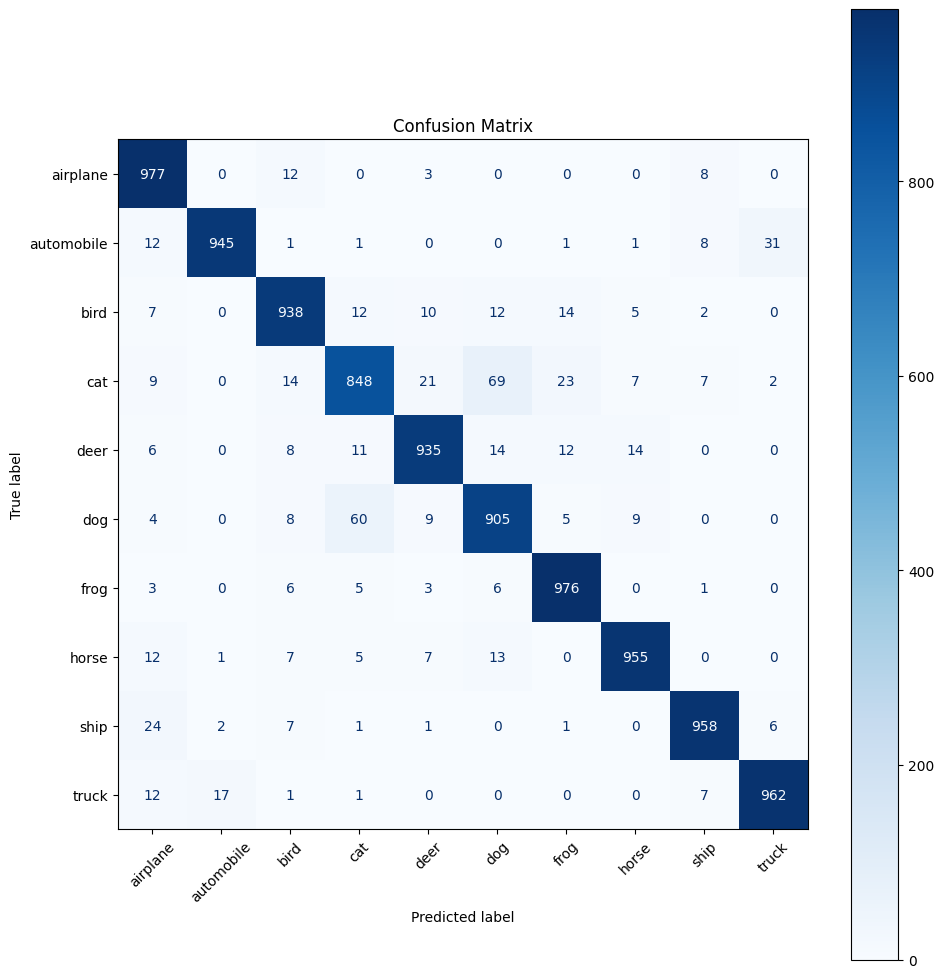

In [15]:
from utils.evaluation import build_confusion_matrix

cm = build_confusion_matrix(
    results["targets"],
    results["predictions"],
)

plot_confusion_matrix(
    matrix=cm,
    class_names=class_names,
    save_path=get_confusion_matrix_path("resnet18_finetune"),
)

## Training Summary

In [16]:
print_summary(results)



Training Summary
Best Accuracy : 0.9441
Training Time : 1634.35 sec
Checkpoint    : C:\Users\pc1\TransferBench\models\best_resnet18_finetune.pth


In [17]:
metrics_df

,Model,Strategy,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,ResNet18,Fine-Tuning,0.9399,0.940089,0.9399,0.939756,1634.346132


In [18]:
results

{'history': {'train_loss': [0.4492377856731415,
   0.2608672384762764,
   0.19848759569048882,
   0.1552593249619007,
   0.12936381059110164,
   0.10701256559371948,
   0.08759123497441411,
   0.08041671827942133,
   0.07167239524818957,
   0.059887982149608436,
   0.05721211034793407,
   0.05163346126336604,
   0.04601999889678322,
   0.04379207433359698,
   0.041484489515908066,
   0.04130724165795371,
   0.034452243855446575,
   0.023240118658868596,
   0.01893587219359819,
   0.01656217468202114],
  'train_acc': [0.84856,
   0.9105,
   0.93264,
   0.94656,
   0.9562,
   0.96342,
   0.97022,
   0.97284,
   0.9758,
   0.9799,
   0.98066,
   0.98258,
   0.98402,
   0.98436,
   0.98556,
   0.98638,
   0.98856,
   0.99272,
   0.99364,
   0.99454],
  'val_loss': [0.2706289306759834,
   0.23334031166136265,
   0.2286459606900811,
   0.2214760700583458,
   0.21561549206376077,
   0.2153573096513748,
   0.22254569790065287,
   0.21725015807300807,
   0.21892254000380634,
   0.22720620756484

## Generated Files

In [19]:
print("Model File")
print(get_model_path("best_resnet18_finetune"))

print()

print("Metrics")
print(get_metrics_path("resnet18_finetune"))

print()

print("Loss Plot")
print(get_loss_plot_path("resnet18_finetune"))

print()

print("Accuracy Plot")
print(get_accuracy_plot_path("resnet18_finetune"))

print()

print("Confusion Matrix")
print(get_confusion_matrix_path("resnet18_finetune"))

Model File
C:\Users\pc1\TransferBench\models\best_resnet18_finetune.pth

Metrics
C:\Users\pc1\TransferBench\results\resnet18_finetune_metrics.csv

Loss Plot
C:\Users\pc1\TransferBench\figures\resnet18_finetune_loss.png

Accuracy Plot
C:\Users\pc1\TransferBench\figures\resnet18_finetune_accuracy.png

Confusion Matrix
C:\Users\pc1\TransferBench\figures\confusion_matrix_resnet18_finetune.png
